## Week 1 · Data augmentation  🎨

Deep-learning models generalise better when they see **a lot of varied data**, but recording and labelling frames is slow. **Data augmentation** allows you to increase the number of available samples by creating modified copies of them: flipping, cropping, blurring, changing brightness, shifting colours...

Each copy looks different to the model yet shows the same scene, so the model learns to be **robust** to changes in viewpoint, lighting and image quality instead of memorising the training frames. This usually improves accuracy and reduces overfitting at no extra labelling cost.

Two things to keep in mind:
- **The labels move with the image.** When a frame is flipped or cropped its bounding boxes must be transformed too. The augmentation library does this for us.
- **Only augment real data.** Augmenting already-augmented frames piles distortion on distortion without adding information, so we always start from the original sequences. The notebook does this for us.

**Where to find augmentations.** We use the `albumentations` library, whose transforms are documented across two pages:
- [albumentations.ai/explore](https://albumentations.ai/explore/) — a visual gallery that shows what each transform *does* to an image (results only, no code).
- [albumentations.ai/docs/api-reference](https://albumentations.ai/docs/api-reference/) — the API reference; open a transform group (e.g. *Blur*, *Geometric*) and then its *transforms* page to get the class name, its parameters and a code example.

Augmented frames are written to a new `<sequence>-aug/` folder next to each original sequence:

```
dataset/
├── Video_1/       # original sequence
│   ├── images/
│   └── labels/
└── Video_1-aug/   # augmented copies
    ├── images/
    └── labels/
```

### Imports

In [1]:
import os
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import albumentations as alb

/home/dfc/projects/classes/pids/pids/.pixi/envs/default/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


### Settings

- `PATH_DATA`: folder that holds your sequences.
- `INPUT_SIZE`: `(width, height)` every augmented frame is resized to.

In [22]:
PATH_DATA = '../data_train'      # Folder with the labelled sequences
INPUT_SIZE = (1280, 720)      # (width, height) of the augmented frames
SEED = 10                     # Random seed, so the augmentations are reproducible

### Load the dataset

Read every labelled frame into a list of samples `{'frame_path', 'bboxes', 'labels'}`. Already-augmented sequences are skipped so they are never used as a source.

In [23]:
def list_dir(path):
    """List a folder, skipping caches like __pycache__ and .ipynb_checkpoints."""
    return sorted(e for e in os.listdir(path) if not e.startswith('.') and e != '__pycache__')


def load_labels(xml_path):
    """Read a Pascal VOC .xml file, returning (bboxes, labels)."""
    root = ET.parse(xml_path).getroot()
    bboxes, labels = [], []
    for obj in root.iter('object'):
        box = obj.find('bndbox')
        bboxes.append([int(box.find(c).text) for c in ('xmin', 'ymin', 'xmax', 'ymax')])
        labels.append(obj.find('name').text)
    return bboxes, labels


def load_data(path):
    """Load every labelled frame as {'frame_path', 'bboxes', 'labels'} (augmented sequences excluded)."""
    samples = []
    for seq in list_dir(path):
        seq_dir = os.path.join(path, seq)
        if not os.path.isdir(seq_dir) or seq.endswith('-aug'):
            continue
        labels_dir = os.path.join(seq_dir, 'labels')
        for label_file in list_dir(labels_dir):
            name = os.path.splitext(label_file)[0]
            bboxes, labels = load_labels(os.path.join(labels_dir, label_file))
            samples.append({
                'frame_path': os.path.join(seq_dir, 'images', f'{name}.jpg'),
                'bboxes': bboxes,
                'labels': labels,
            })
    return samples

In [24]:
samples = load_data(PATH_DATA)
print(f'Loaded {len(samples)} labelled frames')

Loaded 605 labelled frames


### Preview frames and boxes

Pass the list of frames you want to inspect and draw them with their bounding boxes to check the labels look right before augmenting.

In [25]:
def draw_frame(ax, image, bboxes, color='tab:green'):
    """Show an image on `ax` with its bounding boxes as coloured outlines."""
    ax.imshow(image)
    ax.axis('off')
    for x_min, y_min, x_max, y_max in bboxes:
        ax.add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                               linewidth=2, edgecolor=color, facecolor='none'))


def show_grid(frames, ncols=2, color='tab:green'):
    """Draw a list of (image, bboxes) pairs in a grid of `ncols` columns."""
    ncols = min(ncols, len(frames))
    nrows = (len(frames) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, (image, bboxes) in zip(axes, frames):
        draw_frame(ax, image, bboxes, color=color)
    for ax in axes[len(frames):]:   # hide unused cells
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def show_batch(samples, ncols=2):
    """Display a list of samples with their bounding boxes (2 columns by default)."""
    show_grid([(plt.imread(s['frame_path']), s['bboxes']) for s in samples], ncols=ncols)

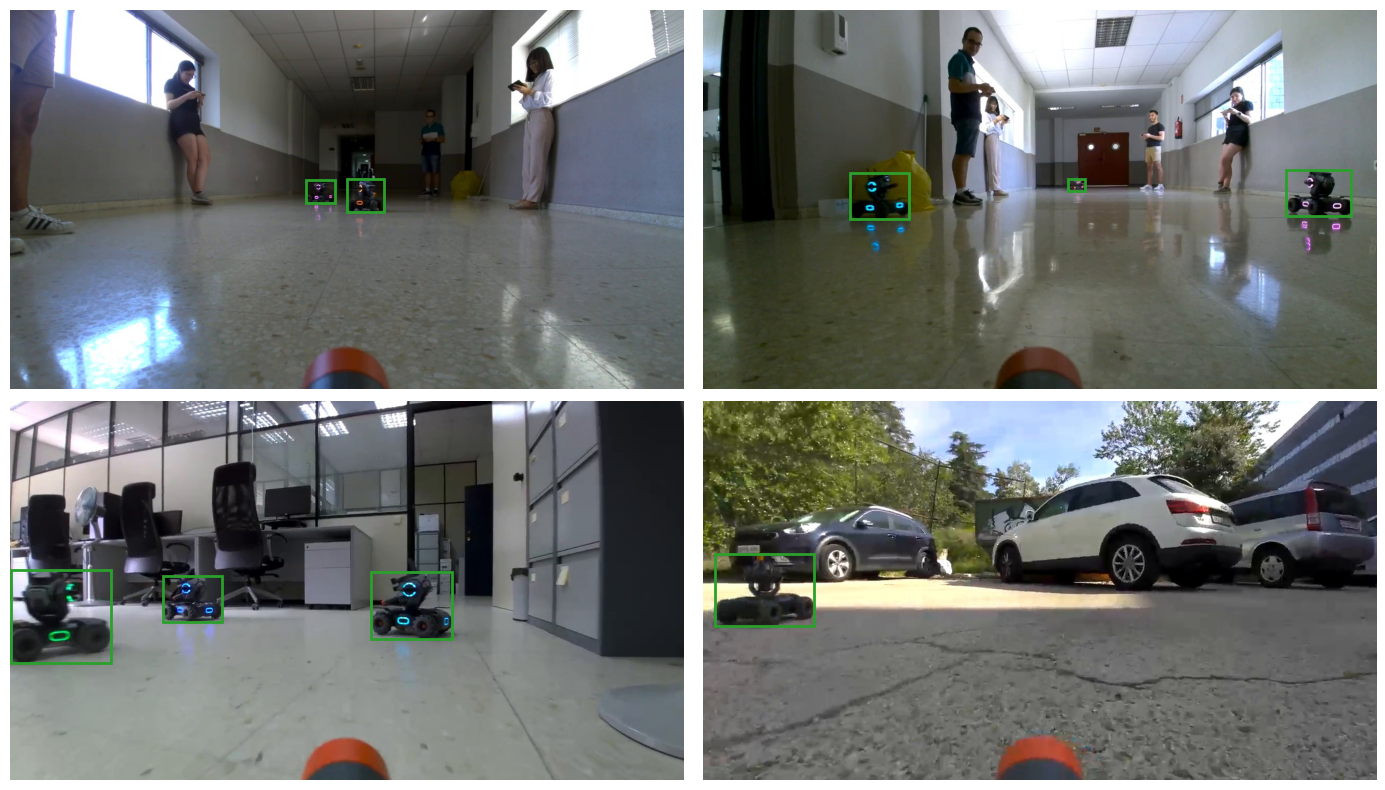

In [26]:
# Pick the frames you want to inspect
show_batch([samples[0], samples[100], samples[200], samples[300]])

### Create the augmentor

The augmentor is an albumentations pipeline: a list of transforms, each applied with some probability `p`. **This is the cell to play with** — comment transforms out, change their parameters or add new ones (see the links at the top of the notebook to browse the available transforms).

`bbox_params` tells albumentations to transform the bounding boxes together with the image and to drop boxes that become too small or barely visible after the transform.

Keep the `Resize` transformation ALWAYS at the end to ensure all the images have the same shape.

In [27]:
def create_augmentor():
    """Build the albumentations augmentation pipeline (edit the transforms here)."""
    width, height = INPUT_SIZE
    return alb.Compose(
        [
            alb.HorizontalFlip(p=0.5),
            alb.Blur(blur_limit=7, p=0.5),
            alb.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.2),
            alb.RandomGamma(gamma_limit=(80, 120), p=0.2),
            alb.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.2),
            alb.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=10, p=0.5),
            alb.RandomCrop(height=480, width=640, p=0.5),
            alb.Resize(height=height, width=width, p=1.0), # Keep this transformation ALWAYS at the end!!!
        ],
        bbox_params=alb.BboxParams(format='pascal_voc', min_area=100, min_visibility=0.3, label_fields=['labels']),
    )

In [28]:
augmentor = create_augmentor()

### Preview an augmentation

Apply the augmentor to a list of frames: repeat a frame to see the variety of transforms it can receive, or pass different frames to compare — the boxes always follow the image. The preview is seeded with `SEED`, so it shows the same examples on every run; change `SEED` to see different ones.

In [29]:
def show_augmentation(augmentor, samples, ncols=2):
    """Display one augmented version of each sample (repeat a sample to see its augmentation variety)."""
    # Seed so the preview is reproducible: the same examples appear on every run
    random.seed(SEED)
    np.random.seed(SEED)
    frames = []
    for s in samples:
        aug = augmentor(image=plt.imread(s['frame_path']), bboxes=s['bboxes'], labels=s['labels'])
        frames.append((aug['image'], aug['bboxes']))
    show_grid(frames, ncols=ncols)

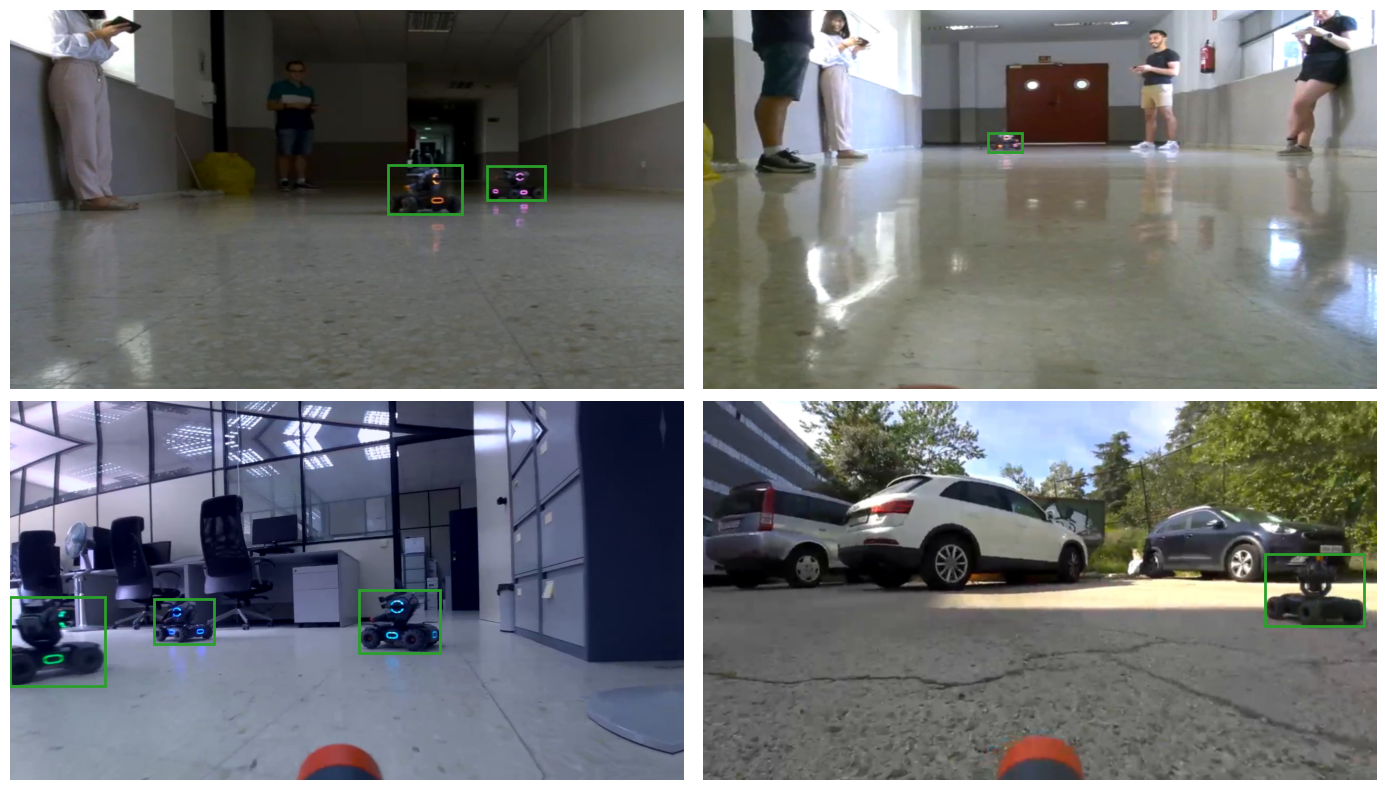

In [30]:
# See the appliedaugmentations
show_augmentation(augmentor, [samples[0], samples[100], samples[200], samples[300]])

### Run data augmentation

For every original sequence, create a sibling `<sequence>-aug/` folder and write `num_augments` augmented copies of each frame (with their transformed labels).

To avoid piling up synthetic data, `-aug` folders are never used as a source, and if a sequence has already been augmented it is **skipped** — set `replace=True` to regenerate it from scratch instead.

The augmentations are seeded with `SEED`, so regenerating always produces the exact same dataset; change `SEED` for a different (but still reproducible) set.

In [11]:
def save_labels(xml_path, bboxes, labels):
    """Write bounding boxes and labels to a Pascal VOC .xml file."""
    width, height = INPUT_SIZE
    filename = f'{os.path.splitext(os.path.basename(xml_path))[0]}.jpg'
    objects = ''.join(
        f"""
    <object>
        <name>{label}</name>
        <bndbox>
            <xmin>{int(x_min)}</xmin>
            <ymin>{int(y_min)}</ymin>
            <xmax>{int(x_max)}</xmax>
            <ymax>{int(y_max)}</ymax>
        </bndbox>
    </object>"""
        for (x_min, y_min, x_max, y_max), label in zip(bboxes, labels)
    )
    with open(xml_path, 'w') as f:
        f.write(f"""<annotation>
    <folder>images</folder>
    <filename>{filename}</filename>
    <size>
        <width>{width}</width>
        <height>{height}</height>
        <depth>3</depth>
    </size>{objects}
</annotation>
""")


def augment_sequence(augmentor, src_dir, dst_dir, num_augments):
    """Augment every labelled frame in src_dir num_augments times into dst_dir."""
    os.makedirs(os.path.join(dst_dir, 'images'))
    os.makedirs(os.path.join(dst_dir, 'labels'))
    for label_file in tqdm(list_dir(os.path.join(src_dir, 'labels')), desc=os.path.basename(dst_dir)):
        name = os.path.splitext(label_file)[0]
        image = plt.imread(os.path.join(src_dir, 'images', f'{name}.jpg'))
        bboxes, labels = load_labels(os.path.join(src_dir, 'labels', label_file))
        for i in range(num_augments):
            aug = augmentor(image=image, bboxes=bboxes, labels=labels)
            stem = f'{name}_aug_{i:02d}'
            plt.imsave(os.path.join(dst_dir, 'images', f'{stem}.jpg'), aug['image'])
            save_labels(os.path.join(dst_dir, 'labels', f'{stem}.xml'), aug['bboxes'], aug['labels'])


def run_data_augmentation(augmentor, num_augments=5, replace=False):
    """Augment every original sequence into a sibling '<sequence>-aug' folder.

    Args:
        augmentor: pipeline from create_augmentor().
        num_augments: number of augmented copies per frame.
        replace: regenerate a sequence that was already augmented (True) or skip it (False).
    """
    # Seed the RNGs so re-running produces exactly the same augmented dataset
    random.seed(SEED)
    np.random.seed(SEED)

    for seq in list_dir(PATH_DATA):
        src_dir = os.path.join(PATH_DATA, seq)
        # Only augment real sequences: skip files and already-augmented folders
        if not os.path.isdir(src_dir) or seq.endswith('-aug'):
            continue

        dst_dir = os.path.join(PATH_DATA, f'{seq}-aug')
        if os.path.exists(dst_dir):
            if not replace:
                print(f'Skipping {seq}: {seq}-aug already exists (use replace=True to regenerate)')
                continue
            print(f'Warning: replacing {seq}-aug')
            shutil.rmtree(dst_dir)

        augment_sequence(augmentor, src_dir, dst_dir, num_augments)

In [12]:
run_data_augmentation(augmentor, num_augments=2, replace=False)

RoboMaster-Stairs-aug: 100%|██████████| 108/108 [00:01<00:00, 57.77it/s]
